# Environmental Data Analytics

## Week 1: Data Collection & Initial Exploration

### Capstone Project – EcoSphere Institute

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Load Datasets

temp_df = pd.read_csv("Temperature_Data.csv")
aq_df = pd.read_csv("Air_Quality_Data.csv")
geo_df = pd.read_csv("Geospatial_Data.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [11]:
#Dataset Shapes

print("Temperature Dataset Shape:", temp_df.shape)
print("Air Quality Dataset Shape:", aq_df.shape)
print("Geospatial Dataset Shape:", geo_df.shape)

Temperature Dataset Shape: (148, 1)
Air Quality Dataset Shape: (29531, 16)
Geospatial Dataset Shape: (6159, 4)


In [12]:
#Dataset Column names
print("Temperature Columns:")
print(temp_df.columns.tolist())

print("\nAir Quality Columns:")
print(aq_df.columns.tolist())

print("\nGeospatial Columns:")
print(geo_df.columns.tolist())

Temperature Columns:
['Land-Ocean: Global Means']

Air Quality Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Geospatial Columns:
['Land', 'Year', 'Series', 'Value']


In [13]:
#DataSet Preview
print("Temperature Dataset")
display(temp_df.head())

print("\nAir Quality Dataset")
display(aq_df.head())

print("\nGeospatial Dataset")
display(geo_df.head())

Temperature Dataset


,,,,,,,,,,,,,,,,,,Land-Ocean: Global Means
Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1880,-.19,-.25,-.10,-.17,-.10,-.21,-.19,-.11,-.15,-.24,-.22,-.19,-.18,***,***,-.12,-.17,-.20
1881,-.20,-.16,.02,.04,.06,-.19,.01,-.04,-.15,-.22,-.19,-.07,-.09,-.10,-.18,.04,-.07,-.18
1882,.16,.14,.04,-.16,-.14,-.22,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.08,-.15,-.18
1883,-.29,-.36,-.12,-.18,-.17,-.07,-.07,-.14,-.22,-.11,-.24,-.11,-.17,-.20,-.34,-.16,-.09,-.19



Air Quality Dataset


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



Geospatial Dataset


,Land,Year,Series,Value
0,"Total, all countries or areas",2005,Land area (thousand hectares),1.299769e+07
1,"Total, all countries or areas",2005,Arable land (thousand hectares),1.356869e+06
2,"Total, all countries or areas",2005,Permanent crops (thousand hectares),1.456805e+05
3,"Total, all countries or areas",2005,Forest cover (thousand hectares),4.032743e+06
4,"Total, all countries or areas",2005,Arable land (% of total land area),1.043930e+01


In [14]:
#Missing Value Analysis
print("Temperature Missing Values")
print(temp_df.isnull().sum())

print("\nAir Quality Missing Values")
print(aq_df.isnull().sum())

print("\nGeospatial Missing Values")
print(geo_df.isnull().sum())

Temperature Missing Values
Land-Ocean: Global Means    0
dtype: int64

Air Quality Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Geospatial Missing Values
Land      0
Year      0
Series    0
Value     0
dtype: int64


  level_0 level_1 level_2 level_3 level_4 level_5 level_6 level_7 level_8  \
0    Year     Jan     Feb     Mar     Apr     May     Jun     Jul     Aug   
1    1880    -.19    -.25    -.10    -.17    -.10    -.21    -.19    -.11   
2    1881    -.20    -.16     .02     .04     .06    -.19     .01    -.04   
3    1882     .16     .14     .04    -.16    -.14    -.22    -.16    -.08   
4    1883    -.29    -.36    -.12    -.18    -.17    -.07    -.07    -.14   

  level_9 level_10 level_11 level_12 level_13 level_14 level_15 level_16  \
0     Sep      Oct      Nov      Dec      J-D      D-N      DJF      MAM   
1    -.15     -.24     -.22     -.19     -.18      ***      ***     -.12   
2    -.15     -.22     -.19     -.07     -.09     -.10     -.18      .04   
3    -.15     -.23     -.17     -.36     -.11     -.09      .08     -.08   
4    -.22     -.11     -.24     -.11     -.17     -.20     -.34     -.16   

  level_17 Land-Ocean: Global Means  
0      JJA                      SON  
1   

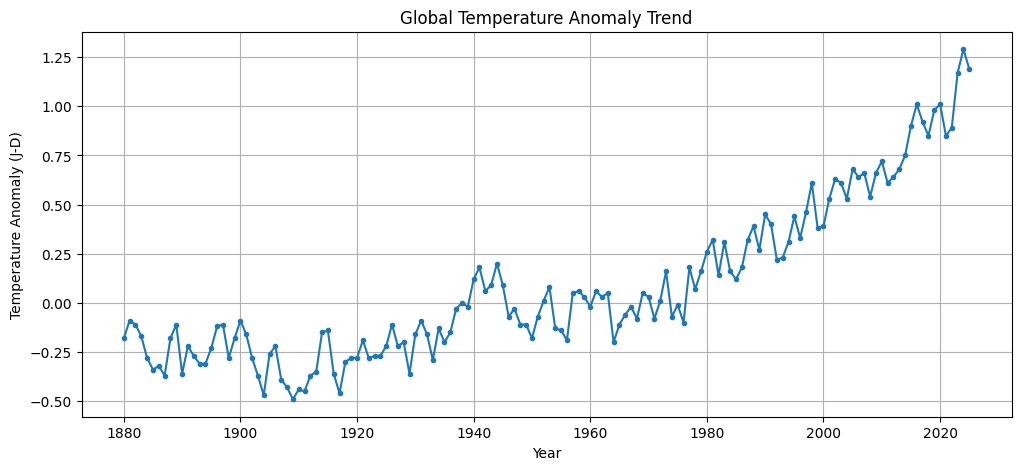

In [21]:
# Temperature Trend Graph
# Convert the index (years) and J-D column to numeric

temp_plot = temp_df.copy()

temp_plot = temp_plot.reset_index()

print(temp_plot.head())

# Rename columns for convenience
temp_plot.columns = ['Year','Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec',
                     'J-D','D-N','DJF','MAM','JJA','SON']

temp_plot['Year'] = pd.to_numeric(temp_plot['Year'], errors='coerce')
temp_plot['J-D'] = pd.to_numeric(temp_plot['J-D'], errors='coerce')

plt.figure(figsize=(12,5))
plt.plot(temp_plot['Year'], temp_plot['J-D'], marker='.')

plt.title('Global Temperature Anomaly Trend')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (J-D)')
plt.grid(True)

plt.show()

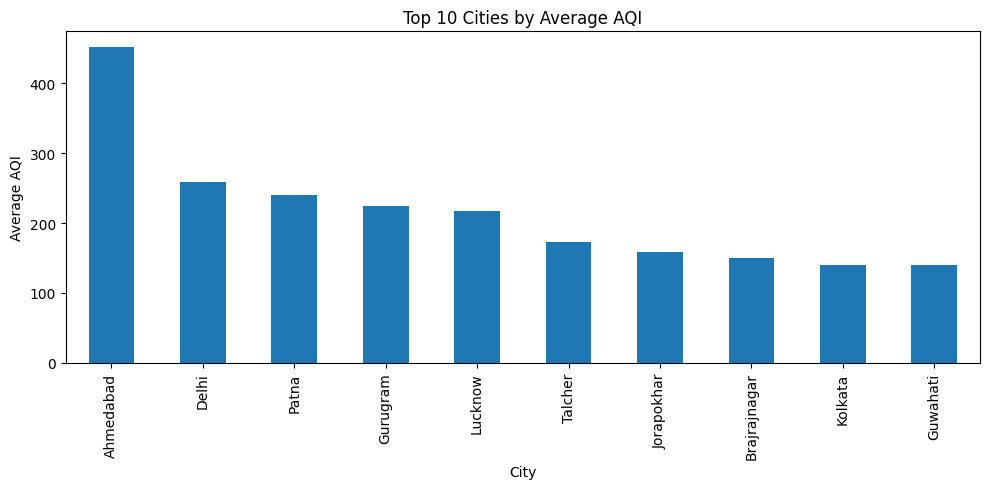

In [19]:
#Air Quality Graph
city_aqi = (
    aq_df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
city_aqi.plot(kind="bar")

plt.title("Top 10 Cities by Average AQI")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

C:\Users\kvahi\AppData\Local\Temp\ipykernel_29888\2212101262.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


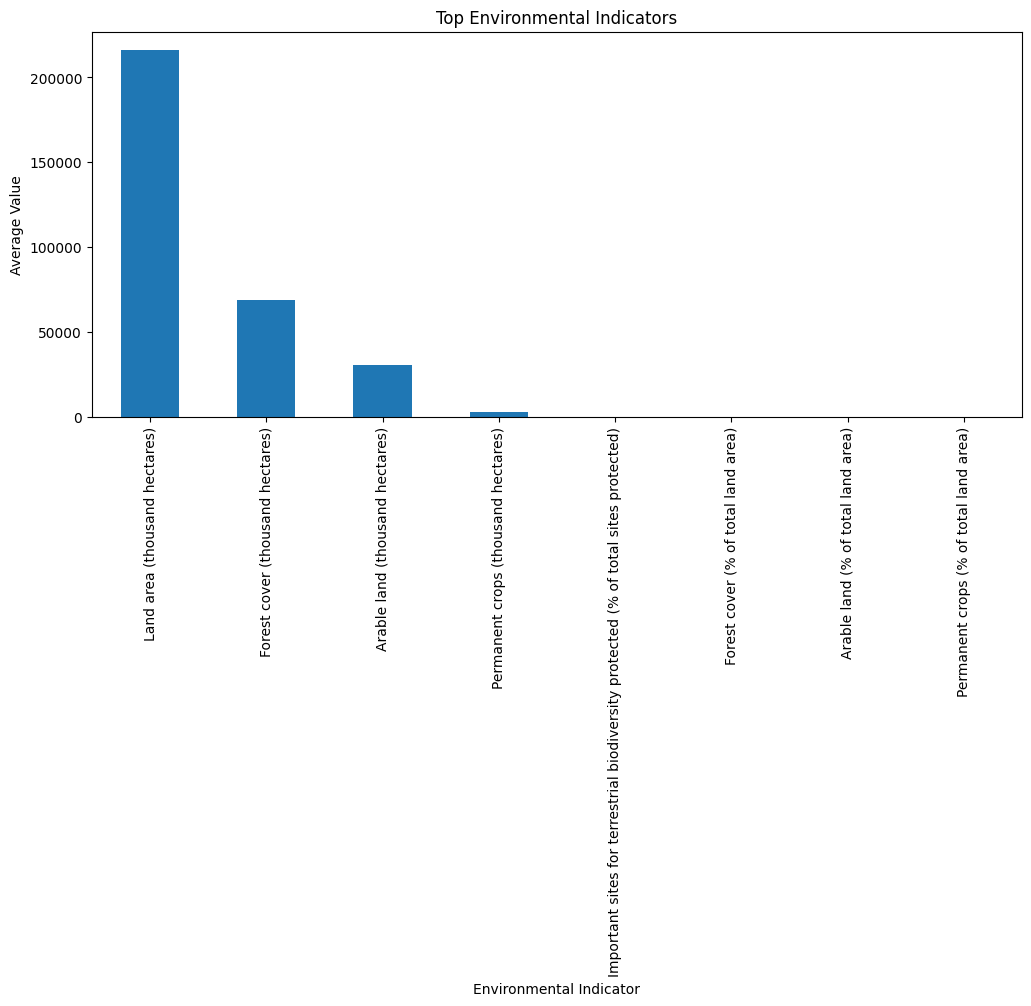

In [20]:
# Geospatial Graph

geo_summary = (
    geo_df.groupby("Series")["Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
geo_summary.plot(kind="bar")

plt.title("Top Environmental Indicators")
plt.xlabel("Environmental Indicator")
plt.ylabel("Average Value")

plt.tight_layout()
plt.show()

# Observations

### Temperature Dataset

- The global temperature anomaly dataset shows a clear long-term warming trend from 1880 to the present.
- Temperature anomalies increased significantly after 1980.
- Recent years exhibit the highest recorded temperature anomalies, indicating accelerating global warming patterns.

### Air Quality Dataset
- Significant variation in AQI values was observed across cities.
- Ahmedabad recorded the highest average AQI among the top 10 cities analyzed.
- The dataset contains several missing values that will be handled during preprocessing.

### Geospatial Dataset
- Land area and forest cover indicators dominate the environmental dataset.
- Environmental indicators vary considerably across regions and land-use categories.
- The dataset appears complete with no missing values.

# Conclusion

Week 1 focused on identifying, collecting, and performing initial exploration of environmental datasets.

Three datasets covering temperature, air quality, and geospatial indicators were successfully acquired and analyzed.

Initial exploratory analysis provided insights into dataset structure, missing values, environmental indicators, and urban air quality patterns.

These findings establish a strong foundation for data cleaning, preprocessing, and integration activities planned for Week 2.